# Fine-tuning (LoRA)

This notebook focuses on adapting a pre-trained instruction-tuned language model using LoRA for rubric-based customer support reply evaluation.

The objective is to improve scoring quality compared to the baseline model while keeping training efficient through parameter-efficient fine-tuning.

The notebook will:

- Load and prepare the dataset.
- Convert samples into instruction-tuning format.
- Load the base instruction-tuned model.
- Apply LoRA adaptation.
- Run multiple fine-tuning experiments.
- Evaluate each experiment using Accuracy, MAE, and QWK.
- Compare results and save the best-performing model.

## 1. Setup and Imports

This section prepares the environment by importing all required libraries for dataset handling, model loading, and LoRA fine-tuning using HuggingFace.

In [1]:
import os
import sys
import json
import random
import re

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

from peft import (LoraConfig,get_peft_model,TaskType)

from sklearn.metrics import (accuracy_score,mean_absolute_error,cohen_kappa_score)

sys.path.append("..")
from src.prompts import build_prompt
from src.generate_response import generate_response
from src.extract_prediction import extract_prediction
from src.get_accuracy import get_accuracy

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2. Load Dataset

In this section, we load the prepared dataset splits (train, validation, and test) that were created during the data preparation phase.

These datasets are stored in .jsonl format and contain the full structured evaluation fields required for instruction

In [2]:
def load_jsonl(path):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)

train_df = load_jsonl("../data/train.jsonl")
val_df = load_jsonl("../data/val.jsonl")
test_df = load_jsonl("../data/test.jsonl")

print("Train Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

train_df.head(1)

Train Shape: (160, 9)
Validation Shape: (20, 9)
Test Shape: (20, 9)


,task,reference,submission,rubric,score,rationale,reference_length,submission_length,rationale_length
0,Customer reports that the product they receive...,We sincerely apologize that the product you re...,Descriptions may vary slightly. Please check t...,"{'1': 'Shows understanding and apology', '2': ...",1,The reply minimizes the customer's concern and...,60,10,25


## 3. Prepare Instruction-Tuning Dataset

In this section, we convert the raw dataset into an instruction-tuning format that the model can learn from during fine-tuning.

Each sample is transformed into a single training text that includes:

- The instruction (task + reference + submission + rubric)
- The expected output (score + rationale)

This format teaches the model to directly generate structured JSON responses during training.

In [3]:
def build_training_example(row):
    target = json.dumps(              # dumps : from a Python object to a JSON string because the model will be trained to generate this string
        {
            "score": row["score"],
            "rationale": row["rationale"]
        }
    )
    text = build_prompt(row) + "\n\n### Response:\n" + target
    return {"text": text}

train_dataset = Dataset.from_pandas(train_df) # from_pandas : pandas DataFrame -> Hugging Face Dataset because the Trainer works with Hugging Face Datasets
val_dataset   = Dataset.from_pandas(val_df) 

train_dataset = train_dataset.map(build_training_example)
val_dataset   = val_dataset.map(build_training_example)

print(train_dataset[0]["text"])


Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

You are an expert evaluator for customer support replies.
Evaluate the quality of the submission.
Return ONLY valid JSON.

Format:
{
    "score": integer from 0 to 4, where 0 is the worst and 4 is the best,
    "rationale": "short explanation"
}

Task:
Customer reports that the product they received does not match the description shown on the website and requests a solution.

Reference:
We sincerely apologize that the product you received did not match the description on our website. We completely understand how disappointing this must be. We can offer you either a full refund or an exchange for the correct item at no additional cost. Please let us know which option you prefer and we will take care of it right away.

Submission:
Descriptions may vary slightly. Please check the product page again.

Rubric:
1. Shows understanding and apology
2. Provides correct and relevant information
3. Provides clear solution or next step
4. Uses polite and professional tone

### Response:
{"score": 1

## 4. Load Base Model and Tokenizer

In this section, we load the pre-trained instruction-tuned language model (Mistral-7B-Instruct 4-bit version) along with its tokenizer.

This model is the starting point for fine-tuning using LoRA. We keep it unchanged at this stage to ensure a fair comparison between baseline and fine-tuned performance.

We also configure padding settings to ensure stable batching during training.

In [4]:
MODEL_NAME = "unsloth/mistral-7b-instruct-v0.2-bnb-4bit"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

tokenizer.pad_token     = tokenizer.eos_token 
tokenizer.padding_side  = "right" 
# example of right padding:
# Hello world  Hello world
# Hi           Hi <PAD>

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto"
)
model.config.pad_token_id = tokenizer.eos_token_id 

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Loading tokenizer...


Loading model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Using device: cuda


## 5. Define Experiment Function 

In this section, we define a reusable experiment pipeline that allows us to run multiple fine-tuning configurations without duplicating code.

This function handles the full workflow:

- Applying LoRA configuration
- Preparing tokenized datasets
- Training the model
- Evaluating on the validation/test set
- Returning performance metrics (Accuracy, MAE, QWK)

This design enables controlled experiments by changing only hyperparameters such as:

- LoRA rank (r)
- Learning rate
- Number of epochs
- Target modules

In [5]:
def run_experiment(
    train_dataset,
    val_dataset,
    test_df,
    tokenizer,
    base_model,
    lora_config,
    training_args,
    device,
    num_samples=50
):

    base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto"
    )

    model = get_peft_model(base_model, lora_config)

    def tokenize_fn(example):
        tokens = tokenizer(
            example["text"],
            truncation=True, # truncation : if the input text is longer than max_length, it will be truncated to max_length
            padding="max_length", # padding : if the input text is shorter than max_length, it will be padded to max_length
            max_length=1024
        )
        tokens["labels"] = tokens["input_ids"].copy()
        return tokens

    train_tok = train_dataset.map(tokenize_fn)
    val_tok   = val_dataset.map(tokenize_fn)

    train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    val_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=False
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        data_collator=data_collator
    )

    trainer.train()

    acc, y_true, y_pred = get_accuracy(
        model,
        tokenizer,
        test_df,
        device,
        num_samples=num_samples
    )

    mae = mean_absolute_error(y_true, y_pred)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    return {
        "model": model,
        "accuracy": acc,
        "mae": mae,
        "qwk": qwk
    }

## 6. Experiment 1 — Default LoRA

In this experiment, we evaluate the default LoRA configuration as the baseline fine-tuning setup.

This configuration represents a standard and stable setting commonly used for parameter-efficient fine-tuning.

We keep all training settings fixed to ensure fair comparison with future experiments, where only one variable will be changed at a time.


In [6]:
lora_config_exp1 = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"]
)

training_args_exp1 = TrainingArguments(
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    eval_strategy="no",
    save_strategy="no",
    report_to="none"
)

results_exp1 = run_experiment(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_df=test_df,
    tokenizer=tokenizer,
    base_model=model,
    lora_config=lora_config_exp1,
    training_args=training_args_exp1,
    device=device,
    num_samples=50
)

print("Experiment 1 Results:")
print(results_exp1)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Step,Training Loss
10,1.477857
20,0.696790
30,0.544723
40,0.486575
50,0.413510
60,0.401821


[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hug


--- Evaluation Results ---
Accuracy: 0.8500
MAE:      0.1500
QWK:      0.9630
Experiment 1 Results:
{'model': PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32000, 4096, padding_idx=0)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lo

## 7. Experiment 2 — Higher LoRA Rank

In this experiment, we increase the LoRA rank (r) to evaluate whether a higher-rank adaptation improves model performance.

The LoRA rank controls the capacity of the low-rank adaptation matrices. Increasing it allows the model to learn more task-specific patterns, but may also increase overfitting risk and computational cost.

We keep all other hyperparameters fixed to ensure a fair comparison with Experiment 1.

In [7]:
lora_config_exp2 = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,  ## Try increasing the rank to 16
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"]
)

training_args_exp2 = TrainingArguments(
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    eval_strategy="no",
    save_strategy="no",
    report_to="none"
)

results_exp2 = run_experiment(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_df=test_df,
    tokenizer=tokenizer,
    base_model=model,
    lora_config=lora_config_exp2,
    training_args=training_args_exp2,
    device=device,
    num_samples=50
)

print("Experiment 2 Results:")
print(results_exp2)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Step,Training Loss
10,1.475567
20,0.697663
30,0.549512
40,0.493574
50,0.423129
60,0.411425


[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hug


--- Evaluation Results ---
Accuracy: 0.8500
MAE:      0.1500
QWK:      0.9630
Experiment 2 Results:
{'model': PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32000, 4096, padding_idx=0)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (

## 8. Experiment 3 — Lower Learning Rate

In this experiment, we investigate the effect of reducing the learning rate on model performance.

The learning rate controls how much the model updates its weights during training. A lower learning rate can lead to more stable training and better generalization, especially on small datasets, but it may also slow down convergence.

We keep all other hyperparameters fixed to ensure a fair comparison with previous experiments.

In [8]:
lora_config_exp3 = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"]
)

training_args_exp3 = TrainingArguments(
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=1e-4,  # lower LR (changed)
    fp16=True,
    logging_steps=10,
    eval_strategy="no",
    save_strategy="no",
    report_to="none"
)

results_exp3 = run_experiment(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_df=test_df,
    tokenizer=tokenizer,
    base_model=model,
    lora_config=lora_config_exp3,
    training_args=training_args_exp3,
    device=device,
    num_samples=50
)

print("Experiment 3 Results:")
print(results_exp3)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Step,Training Loss
10,1.692283
20,1.064419
30,0.719189
40,0.615363
50,0.565323
60,0.551091


[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hug


--- Evaluation Results ---
Accuracy: 0.8500
MAE:      0.1500
QWK:      0.9630
Experiment 3 Results:
{'model': PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32000, 4096, padding_idx=0)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lo

## 9. Experiment 4 — More Epochs

In this experiment, we increase the number of training epochs to evaluate whether longer training improves the model’s ability to learn the rubric-based evaluation task.

Training for more epochs allows the model to see the dataset multiple times, which may improve learning, but it can also lead to overfitting, especially on small datasets.

All other hyperparameters are kept fixed for a fair comparison.

In [9]:
lora_config_exp4 = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"]
)

training_args_exp4 = TrainingArguments(
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=5,  # more epochs (changed)
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    eval_strategy="no",
    save_strategy="no",
    report_to="none"
)

results_exp4 = run_experiment(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_df=test_df,
    tokenizer=tokenizer,
    base_model=model,
    lora_config=lora_config_exp4,
    training_args=training_args_exp4,
    device=device,
    num_samples=50
)

print("Experiment 4 Results:")
print(results_exp4)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Step,Training Loss
10,1.465409
20,0.681338
30,0.530080
40,0.460713
50,0.364390
60,0.335766
70,0.271832
80,0.265743
90,0.238094
100,0.224982


[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hug


--- Evaluation Results ---
Accuracy: 0.8500
MAE:      0.1500
QWK:      0.9630
Experiment 4 Results:
{'model': PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32000, 4096, padding_idx=0)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lo

## 10. Experiment 5 — More Target Modules

In this experiment, we increase the number of LoRA target modules to allow the model to adapt more layers of the transformer architecture.

Previously, we only adapted the attention projection layers (q_proj and v_proj). In this experiment, we expand adaptation to additional modules to increase model flexibility and learning capacity.

All other hyperparameters are kept fixed to ensure a fair comparison.

In [10]:
lora_config_exp5 = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"] # Try expanding to all 4 projection layers (changed)
)

training_args_exp5 = TrainingArguments(
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    eval_strategy="no",
    save_strategy="no",
    report_to="none"
)

results_exp5 = run_experiment(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_df=test_df,
    tokenizer=tokenizer,
    base_model=model,
    lora_config=lora_config_exp5,
    training_args=training_args_exp5,
    device=device,
    num_samples=50
)

print("Experiment 5 Results:")
print(results_exp5)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Step,Training Loss
10,1.229557
20,0.569360
30,0.431637
40,0.372122
50,0.284828
60,0.273919


[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hug


--- Evaluation Results ---
Accuracy: 0.9000
MAE:      0.1000
QWK:      0.9744
Experiment 5 Results:
{'model': PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32000, 4096, padding_idx=0)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lo

## 11. Compare All Experiments

In this section, we compare the results of all five experiments to analyze the impact of different LoRA configurations and training hyperparameters.

We evaluate each experiment using three metrics:
- Accuracy (exact match of predicted score)
- MAE (Mean Absolute Error)
- QWK (Quadratic Weighted Kappa)

This comparison helps identify the best-performing configuration for the rubric-based evaluation task.

Best Experiment:
Experiment    Exp5 (More Modules)
Accuracy                      0.9
MAE                           0.1
QWK                      0.974359
Name: 4, dtype: object


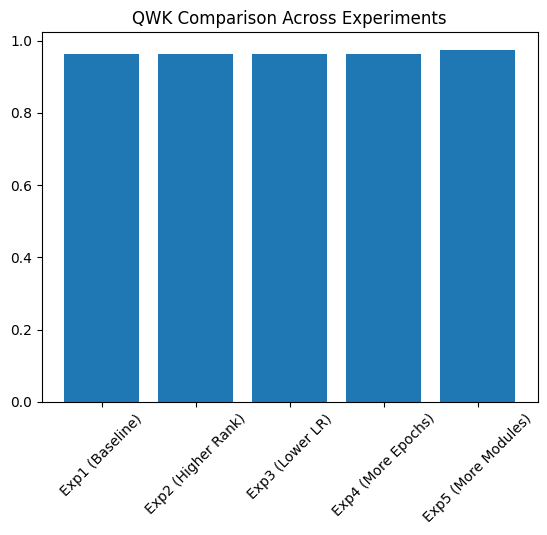

In [11]:
results = {
    "Exp1 (Baseline)": results_exp1,
    "Exp2 (Higher Rank)": results_exp2,
    "Exp3 (Lower LR)": results_exp3,
    "Exp4 (More Epochs)": results_exp4,
    "Exp5 (More Modules)": results_exp5
}

comparison_df = pd.DataFrame({
    "Experiment": [],
    "Accuracy": [],
    "MAE": [],
    "QWK": []
})

for name, res in results.items():
    comparison_df = pd.concat([comparison_df, pd.DataFrame([{
        "Experiment": name,
        "Accuracy": res["accuracy"],
        "MAE": res["mae"],
        "QWK": res["qwk"]
    }])], ignore_index=True)

comparison_df

best_exp = comparison_df.sort_values(by="QWK", ascending=False).iloc[0]
print("Best Experiment:")
print(best_exp)

plt.figure()
plt.bar(comparison_df["Experiment"], comparison_df["QWK"])
plt.xticks(rotation=45)
plt.title("QWK Comparison Across Experiments")
plt.show()

## 12. Save Best Model

In this section, we save the best-performing fine-tuned LoRA model based on the highest QWK score.

Saving the model allows us to reuse it later for inference and deployment without retraining.

In [12]:
best_index = comparison_df["QWK"].idxmax()
best_experiment_name = comparison_df.loc[best_index, "Experiment"]
print("Best Experiment:", best_experiment_name)

experiments_models = {
    "Exp1 (Baseline)": results_exp1["model"],
    "Exp2 (Higher Rank)": results_exp2["model"],
    "Exp3 (Lower LR)": results_exp3["model"],
    "Exp4 (More Epochs)": results_exp4["model"],
    "Exp5 (More Modules)": results_exp5["model"]
}
best_model = experiments_models[best_experiment_name]

save_path = "../models/best_lora_model"
os.makedirs(save_path, exist_ok=True)

best_model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Best model saved successfully at: {save_path}")

Best Experiment: Exp5 (More Modules)
Best model saved successfully at: ../models/best_lora_model


## 13. Summary

This project focused on building an automatic rubric-based evaluation system using an instruction-tuned transformer model (Mistral-7B-Instruct v0.2 with 4-bit quantization). The goal was to evaluate customer support responses by predicting a discrete score (0–4) along with a natural language rationale.

We prepared a structured dataset containing five key components: task description, reference answer, submission, rubric, score, and rationale. Each example was converted into an instruction-tuning format to train the model in a supervised manner.

To improve performance, we applied Parameter-Efficient Fine-Tuning using LoRA (Low-Rank Adaptation). Instead of updating all model parameters, only a small subset of trainable parameters was optimized, making training efficient and suitable for limited GPU resources.

We designed five controlled experiments to study the effect of different hyperparameters:

- Experiment 1: Default LoRA configuration (baseline fine-tuning setup)
- Experiment 2: Increased LoRA rank
- Experiment 3: Lower learning rate
- Experiment 4: More training epochs
- Experiment 5: Expanded target modules

Each experiment was evaluated using Accuracy, Mean Absolute Error (MAE), and Quadratic Weighted Kappa (QWK), which is especially suitable for ordinal scoring tasks.

Results showed that performance varied across configurations, with QWK being the most stable and reliable metric for comparison. Increasing model capacity or training time did not always guarantee better performance, highlighting the importance of balanced hyperparameter selection.

Finally, the best-performing model was selected based on QWK score and saved for future inference. Overall, the project demonstrates the effectiveness of LoRA-based fine-tuning for building lightweight yet powerful evaluation systems.